# 자세 판별 모델 학습 (통합 노트북)

정면 웹캠 영상 → MediaPipe Pose 좌표 → 어깨너비 정규화 피처 → 로지스틱 회귀 → 모델 JSON.

**자세 3종을 각각 독립 이진 분류기로 학습합니다** — 거북목 / 라운드숄더 / 어깨높낮이.
3종은 동시에 나타날 수 있어서(거북목이면서 라운드숄더) 다중분류가 아니라 이진 분류기 3개입니다.
백엔드도 3종을 독립 판정하므로 모델 JSON도 3개가 나옵니다.

모든 코드(설정·피처·추출·학습·검증)를 이 노트북에 통합했습니다 (외부 `.py` import 없음).

> **⚠️ 검증은 반드시 사람 단위로 나눕니다.**
> 프레임 단위로 무작위 분할하면 0.03초 차이 나는 거의 동일한 프레임이 학습셋과 검증셋에
> 같이 들어가서, 정확도가 실제보다 훨씬 높게 나옵니다. 답을 보고 시험 보는 것과 같습니다.
> 그래서 `person` 열을 두고 **한 사람을 통째로 빼서 검증**합니다. 신규 사용자가 쓰는 상황과 같은 조건입니다.

> **⚠️ `compute_features` 로직은 프론트(JS) 추론과 100% 동일해야 합니다.**
> 대응 코드: `backend/src/main/resources/static/posture-lab.html` 의 `extractMlFeatures()`

## 0. 준비 & import

- `(turtleneck)` 가상환경에서 실행 / `pip install -r requirements.txt`
- 이 노트북은 `ai/` 폴더에서 실행하세요 (작업 디렉터리 = ai).

In [1]:
import csv, json, math
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import mediapipe as mp
from sklearn.linear_model import LogisticRegression
# fbeta_score 하나로 F0.5 / F1 / F2 를 모두 낸다 (f1_score 는 fbeta_score(beta=1) 과 같다).
from sklearn.metrics import (classification_report, confusion_matrix, fbeta_score,
                             make_scorer)
# GroupKFold / LeaveOneGroupOut = 사람 단위 분할. cross_val_predict = 검증 폴드에서의 예측을 모아 준다.
# cross_val_score 대신 cross_validate 를 쓴다 — 지표를 여러 개 넘기면 폴드마다 한 번씩만
# 학습하고 F0.5/F1/F2 를 같이 돌려준다(세 번 돌리는 것보다 빠르고, 폴드가 정확히 같다).
from sklearn.model_selection import (GroupKFold, LeaveOneGroupOut,
                                     cross_val_predict, cross_validate)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# 한글 폰트 (Windows 기본 제공) — 그래프 라벨 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

mp_pose = mp.solutions.pose
print('import 완료')

import 완료


## 1. 설정 (경로 · 랜드마크 · 피처 순서 · 판정 경계)

In [ ]:
# 경로 (노트북이 어디서 열렸든 ai/ 를 자동으로 찾는다)
AI_ROOT = Path.cwd()
if not (AI_ROOT / 'data' / 'raw').exists():
    if (AI_ROOT / 'ai' / 'data' / 'raw').exists():
        AI_ROOT = AI_ROOT / 'ai'
if AI_ROOT.name == 'src':
    AI_ROOT = AI_ROOT.parent
RAW_DIR = AI_ROOT / 'data' / 'raw'            # 원본 영상 + labels.csv
LANDMARKS_DIR = AI_ROOT / 'data' / 'landmarks'  # 추출된 좌표 CSV (자동 생성)
MODELS_DIR = AI_ROOT / 'models'                 # 학습 결과 JSON
MANIFEST_PATH = RAW_DIR / 'labels.csv'          # 영상별 라벨·촬영자

# MediaPipe Pose 랜드마크 인덱스 (필요한 것만)
POSE_LANDMARKS = {
    'nose': 0,
    'left_eye': 2, 'right_eye': 5,
    'left_ear': 7, 'right_ear': 8,
    'left_shoulder': 11, 'right_shoulder': 12,
}
LANDMARK_NAMES = list(POSE_LANDMARKS.keys())

# BlazePose 모델 등급. 0=lite / 1=full / 2=heavy.
#
# ⚠️ 프론트가 로드하는 등급과 반드시 같아야 한다.
#    frontend/src/lib/pose/poseLandmarker.ts 의 MODEL_PATH → pose_landmarker_heavy.task
#    backend/src/main/resources/static/posture-lab.html 의 modelAssetPath
#
# 등급이 다르면 좌표가, 특히 z(깊이)가 다르게 나온다. z 기반 피처(nose_z_rel, ear_z_rel,
# acromion_proxy, shoulder_z_rel, shoulder_z_spread)가 5개나 되므로 학습 때와 추론 때
# 분포가 어긋나고, 그 결과는 "에러 없이 그럴듯하게 틀린 판정"이라 발견하기 어렵다.
POSE_MODEL_COMPLEXITY = 2  # heavy — 프론트 pose_landmarker_heavy.task 와 맞춤

# 자세 3종. 각각 독립 이진 분류기로 학습한다(0=정상, 1=해당 자세 있음).
# 동시에 나타날 수 있어서 다중분류로 묶으면 "둘 다"를 표현할 수 없다.
LABELS = ['forward_head', 'rounded_shoulder', 'shoulder_tilt']
LABEL_NAMES_KO = {
    'forward_head': '거북목',
    'rounded_shoulder': '라운드숄더',
    'shoulder_tilt': '어깨높낮이',
}
# 백엔드 application.yml 의 app.posture.hybrid.*-model 이 가리키는 파일명과 같아야 한다.
MODEL_FILES = {
    'forward_head': 'turtleneck_model.json',
    'rounded_shoulder': 'rounded_shoulder_model.json',
    'shoulder_tilt': 'shoulder_tilt_model.json',
}

# 학습 피처 순서 (compute_features 와 반드시 일치)
FEATURE_ORDER = [
    'eye_dist_ratio', 'ear_dist_ratio',
    'nose_above_shoulder', 'ear_above_shoulder',
    'nose_z_rel', 'ear_z_rel',
    'acromion_proxy',  # 귀-어깨 측면거리 근사 (논문 Acromion distance)
    'head_roll',
    # ⚠️ 이름이 'shoulder_tilt' 가 아니라 'shoulder_tilt_signed' 인 이유 (라벨 누수 수정)
    #
    # LABELS 에도 'shoulder_tilt' 가 있어서, load_dataset 이 라벨을 넣을 때
    # feats['shoulder_tilt'] 가 피처값(비율)에서 0/1 라벨로 덮어써지고 있었다.
    # 그 결과 어깨높낮이 모델은 정답을 피처로 받아 F1 1.000 이 나왔고,
    # 거북목·라운드숄더 모델도 "이 사람이 어깨가 기울었는지"를 공짜로 받고 있었다.
    #
    # 백엔드는 이미 고쳐져 있다(PostureMlFeatures.valueOf 가 두 이름을 모두 받는다).
    # 노트북만 옛 이름으로 남아 있어서 재실행하면 누수가 되살아나므로 여기서 맞춘다.
    'shoulder_tilt_signed',
    # ↓ 어깨 관련 자세를 위해 추가한 피처
    # 로지스틱 회귀는 선형이라 부호 있는 값 하나로는 "어느 쪽으로든 기울면 나쁨"을 표현할 수 없다.
    # shoulder_tilt_signed 만 쓰면 왼쪽 기울기를 나쁨으로 배우는 순간 오른쪽 기울기는 "아주 좋은 자세"가 된다.
    'abs_shoulder_tilt', 'abs_head_roll',
    # 라운드숄더는 어깨가 앞으로 말리는 것이라 깊이(z) 신호가 필요하다.
    # shoulder_z_rel(= -nose_z_rel)은 nose_z_rel 과 부호만 다른 같은 값이라 뺐다.
    'shoulder_z_spread',  # 좌우 어깨의 깊이 차 — 몸통 회전과 구분하는 데 쓴다
]

# load_dataset 이 피처 dict 위에 나중에 얹는 열들. 피처가 같은 이름을 쓰면 조용히 덮어써진다.
META_COLUMNS = ['person', 'video']

# ★ 라벨 누수 방지 장치 (3중)
#
# 피처 이름이 라벨·메타 열 이름과 겹치면 load_dataset 에서 피처값이 0/1 라벨로 덮어써진다.
# 에러가 안 나고 정확도만 올라가서 발견하기 매우 어렵다 — 실제로 'shoulder_tilt' 가 그래서
# 어깨높낮이 F1 을 1.000 으로 만들었고, 나머지 두 자세도 "어깨가 기울었는지"를 정답으로 받았다.
#
#   1) 여기            — FEATURE_ORDER 에 겹치는 이름이 있는지 (아래 assert 2개)
#   2) compute_features — 함수가 실제로 돌려준 키가 FEATURE_ORDER 와 같은지 (8번 셀 assert)
#   3) load_dataset     — 라벨을 넣기 직전에 한 번 더 (12번 셀)
#
# 1+2 가 맞물려야 "FEATURE_ORDER 에는 안 적었는데 함수는 돌려주는 피처"까지 걸린다.
_collision = sorted(set(FEATURE_ORDER) & (set(LABELS) | set(META_COLUMNS)))
assert not _collision, (
    f'피처 이름이 라벨/메타 열과 겹칩니다: {_collision}\n'
    f'load_dataset 이 덮어써서 모델이 정답을 피처로 받게 됩니다. 피처 쪽 이름을 바꾸세요\n'
    f"(예: 'shoulder_tilt' -> 'shoulder_tilt_signed'. 백엔드 PostureMlFeatures.valueOf 는 둘 다 받습니다).")

# 12절이 만드는 델타 열(d_*, abs_d_*)과도 겹치면 안 된다. 원본 피처가 그 접두사를 이미 쓰고 있으면
# make_delta_dataset 이 원본을 델타로 덮어쓴다 — 위와 똑같이 조용히 틀린다.
_delta_shadow = sorted(f for f in FEATURE_ORDER if f.startswith(('d_', 'abs_d_')))
assert not _delta_shadow, (
    f'피처 이름이 델타 접두사와 겹칩니다: {_delta_shadow}\n'
    f'12절 make_delta_dataset 이 이 열을 덮어씁니다. 접두사 d_ / abs_d_ 는 델타 전용입니다.')

# 성능 지표. F1 하나만 보는 것은 "정밀도와 재현율이 똑같이 중요하다"는 선언이지 중립이 아니다.
# 이 서비스는 나쁜 자세를 놓치는 쪽(재현율)이 헛알림보다 아프므로 셋을 같이 내고, 채택 판단은
# SELECTION_SCORE 하나로 한다. 나머지 둘은 "지표를 바꾸면 결론이 뒤집히는가"를 보려고 함께 찍는다.
#   F2   — 재현율에 4배 가중. 놓침이 더 나쁘다는 입장 (현재 채택 기준)
#   F1   — 대칭
#   F0.5 — 정밀도에 4배 가중. 공부 중 헛알림이 더 나쁘다는 입장
BETAS = (0.5, 1.0, 2.0)
SCORE_NAMES = [f'F{b:g}' for b in BETAS]   # ['F0.5', 'F1', 'F2']
SELECTION_SCORE = 'F2'
assert SELECTION_SCORE in SCORE_NAMES, f'SELECTION_SCORE 는 {SCORE_NAMES} 중 하나여야 합니다.'

# 3단계 판정 경계 (모델 확률)
#
# 0.4 -> 0.5. 백엔드 severity-probabilities 의 첫 경계(= alert-severity 1 이 걸리는 확률)를
# 0.5 로 올린 것과 맞춘 값이다. 0.5 는 아래 THRESHOLD 이자 F1/F2 를 재는 지점이기도 하다 —
# 경고가 뜨는 확률과 성능을 재는 확률이 다르면 이 노트북의 점수가 서비스 동작을 설명하지 못한다.
LEVEL_WARNING = 0.5  # 이상 → 주의
LEVEL_SEVERE = 0.7   # 이상 → 심각

# 몇 프레임마다 한 장을 쓸지. 30fps 기준 10이면 초당 3장.
# 너무 작게 두면 거의 동일한 프레임만 잔뜩 쌓여 데이터가 늘어난 것처럼 보이지만 정보량은 그대로다.
SAMPLE_EVERY = 10

VIDEO_EXTENSIONS = ('.mp4', '.mov', '.avi', '.webm', '.mkv')
print('AI_ROOT =', AI_ROOT)
print('피처 수:', len(FEATURE_ORDER))
print('Pose 모델:', {0: 'lite', 1: 'full', 2: 'heavy'}[POSE_MODEL_COMPLEXITY])
print('학습할 자세:', ', '.join(LABEL_NAMES_KO[l] for l in LABELS))

In [3]:
import sys
print(sys.executable)

c:\Users\SSAFY\miniforge3\envs\turtleneck\python.exe


## 2. 피처 계산 (⚠️ 프론트 JS 추론과 동일 로직)

좌표를 어깨너비로 정규화한 비율 피처 12종. 이 함수가 학습·추론의 단일 기준입니다.

In [ ]:
def _dist(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

def _midpoint(a, b):
    return [(a[0] + b[0]) / 2, (a[1] + b[1]) / 2, (a[2] + b[2]) / 2]

def compute_features(points):
    """points: {name: [x_px, y_px, z_px, visibility]} → 피처 dict (없으면 None)."""
    nose = points['nose']
    left_eye, right_eye = points['left_eye'], points['right_eye']
    left_ear, right_ear = points['left_ear'], points['right_ear']
    left_shoulder, right_shoulder = points['left_shoulder'], points['right_shoulder']

    shoulder_width = _dist(left_shoulder, right_shoulder)
    if shoulder_width < 1e-6:
        return None
    shoulder_mid = _midpoint(left_shoulder, right_shoulder)
    ear_mid = _midpoint(left_ear, right_ear)
    eye_dist = _dist(left_eye, right_eye)
    if eye_dist < 1e-6:
        return None

    ear_shoulder_dy = ear_mid[1] - shoulder_mid[1]
    ear_shoulder_dz = ear_mid[2] - shoulder_mid[2]
    head_roll = (right_eye[1] - left_eye[1]) / eye_dist
    shoulder_tilt = (right_shoulder[1] - left_shoulder[1]) / shoulder_width
    return {
        'eye_dist_ratio': eye_dist / shoulder_width,
        'ear_dist_ratio': _dist(left_ear, right_ear) / shoulder_width,
        'nose_above_shoulder': (shoulder_mid[1] - nose[1]) / shoulder_width,
        'ear_above_shoulder': (shoulder_mid[1] - ear_mid[1]) / shoulder_width,
        'nose_z_rel': (nose[2] - shoulder_mid[2]) / shoulder_width,
        'ear_z_rel': ear_shoulder_dz / shoulder_width,
        # 귀-어깨 측면(수직+깊이) 2D 거리 근사 (선형으로 못 만드는 비선형 신호)
        'acromion_proxy': math.hypot(ear_shoulder_dy, ear_shoulder_dz) / shoulder_width,
        'head_roll': head_roll,
        # 이름 끝의 _signed 는 라벨 'shoulder_tilt' 와 충돌하지 않게 하려는 것이다.
        # 값의 정의는 그대로이고, 프론트의 shoulderTilt / 백엔드 PostureMlFeatures.shoulderTilt 와 같다.
        # (백엔드 valueOf 는 'shoulder_tilt' 와 'shoulder_tilt_signed' 를 모두 받는다)
        'shoulder_tilt_signed': shoulder_tilt,
        # 어느 쪽으로 기울든 나쁜 자세다. 부호 있는 값만으로는 선형 모델이 한쪽 방향밖에 못 배운다.
        'abs_shoulder_tilt': abs(shoulder_tilt),
        'abs_head_roll': abs(head_roll),
        # 좌우 어깨의 깊이 차. 몸통을 튼 경우에 커지므로 라운드숄더와 회전을 구분하는 데 쓴다.
        'shoulder_z_spread': abs(left_shoulder[2] - right_shoulder[2]) / shoulder_width,
    }

def points_visible(points, min_visibility=0.5):
    for name in POSE_LANDMARKS:
        if name not in points or points[name][3] < min_visibility:
            return False
    return True

# 피처를 추가/변경했으면 FEATURE_ORDER 와 어긋나지 않았는지 여기서 바로 잡는다.
_probe = compute_features({n: [i * 1.0, i * 2.0, i * 0.5, 1.0] for i, n in enumerate(LANDMARK_NAMES, start=1)})
assert _probe is not None and set(_probe) == set(FEATURE_ORDER), \
    f'FEATURE_ORDER 불일치: 함수에만 {set(_probe) - set(FEATURE_ORDER)}, 목록에만 {set(FEATURE_ORDER) - set(_probe)}'
print(f'compute_features 정의 완료 — 피처 {len(FEATURE_ORDER)}개')

## 3. 영상 → 좌표 추출 함수

라벨은 파일명이 아니라 **`data/raw/labels.csv` 매니페스트**에서 읽습니다.

| 열 | 설명 |
|---|---|
| `video` | 파일명 (`data/raw/` 기준) |
| `person` | 촬영자 식별자. **사람 단위 검증에 쓰는 핵심 열** |
| `forward_head` / `rounded_shoulder` / `shoulder_tilt` | 각 0 또는 1 |

```csv
video,person,forward_head,rounded_shoulder,shoulder_tilt
p1_good.mp4,p1,0,0,0
p1_fh.mp4,p1,1,0,0
p1_st_left.mp4,p1,0,0,1
p2_good.mp4,p2,0,0,0
```

파일명 접두사(`good`/`bad`)를 안 쓰는 이유는 둘입니다.
① 라벨이 3개라 파일명 하나로는 표현할 수 없습니다.
② `person` 열이 있어야 사람 단위로 나눌 수 있습니다. 파일명에 다 넣으면 라벨을 고칠 때마다 파일을 바꿔야 합니다.

In [5]:
def load_manifest():
    """data/raw/labels.csv 를 읽어 영상별 라벨·촬영자를 돌려준다.

    라벨 오타(2, 빈칸, 오타난 열 이름)를 여기서 막는다. 그냥 통과시키면 학습이 조용히 망가지고,
    나중에 모델이 이상하게 나왔을 때 원인을 찾기가 매우 어렵다.
    """
    if not MANIFEST_PATH.exists():
        raise FileNotFoundError(
            f'{MANIFEST_PATH} 가 없습니다.\n'
            f'다음 형식으로 만드세요:\n'
            f'  video,person,{",".join(LABELS)}\n'
            f'  p1_good.mp4,p1,0,0,0')

    from io import StringIO
    raw_lines = MANIFEST_PATH.read_text(encoding='utf-8').splitlines()
    cleaned_lines = [
        line[1:-1] if line.startswith('\"') and line.endswith('\"') else line
        for line in raw_lines if line.strip()
    ]
    manifest = pd.read_csv(StringIO('\n'.join(cleaned_lines)))
    required = ['video', 'person'] + LABELS
    missing = [c for c in required if c not in manifest.columns]
    if missing:
        raise ValueError(f'labels.csv 에 열이 없습니다: {missing}\n필요한 열: {required}')

    for label in LABELS:
        invalid = manifest[~manifest[label].isin([0, 1])]
        if len(invalid):
            raise ValueError(f"'{label}' 열에 0/1 이 아닌 값이 있습니다:\n{invalid[['video', label]]}")

    missing_files = [v for v in manifest['video'] if not (RAW_DIR / v).exists()]
    if missing_files:
        raise FileNotFoundError(f'labels.csv 에 적혀 있지만 {RAW_DIR} 에 없는 영상: {missing_files}')

    return manifest


def extract(video_path, person, labels, sample_every=SAMPLE_EVERY):
    """영상 한 개 → 좌표 CSV. person 과 라벨 3종을 매 행에 함께 적는다."""
    video_path = Path(video_path)
    LANDMARKS_DIR.mkdir(parents=True, exist_ok=True)
    out_path = LANDMARKS_DIR / f'{video_path.stem}.csv'

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f'영상 열기 실패: {video_path}')

    header = []
    for name in LANDMARK_NAMES:
        header += [f'{name}_x', f'{name}_y', f'{name}_z', f'{name}_v']
    header += ['person'] + LABELS

    written, frame_idx = 0, 0
    with mp_pose.Pose(static_image_mode=False, model_complexity=POSE_MODEL_COMPLEXITY,
                      min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose, \
         open(out_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(header)
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            frame_idx += 1
            if frame_idx % sample_every != 0:
                continue
            h, w = frame.shape[:2]
            result = pose.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            if not result.pose_landmarks:
                continue
            lm = result.pose_landmarks.landmark
            row = []
            for name in LANDMARK_NAMES:
                p = lm[POSE_LANDMARKS[name]]
                row += [p.x * w, p.y * h, p.z * w, p.visibility]
            row += [person] + [int(labels[l]) for l in LABELS]
            writer.writerow(row)
            written += 1
    cap.release()
    tags = ','.join(LABEL_NAMES_KO[l] for l in LABELS if labels[l] == 1) or '바른자세'
    print(f'완료: {out_path.name} — 프레임 {written}개 (person={person}, {tags})')
    return out_path


def extract_all(sample_every=SAMPLE_EVERY):
    """매니페스트에 적힌 영상을 모두 추출한다. 오래 걸리므로 한 번만 돌리고 CSV를 재사용한다."""
    manifest = load_manifest()
    outputs = []
    for _, row in manifest.iterrows():
        outputs.append(extract(RAW_DIR / row['video'], row['person'], row, sample_every))
    print(f'\n총 {len(outputs)}개 영상 추출 완료 (촬영자 {manifest["person"].nunique()}명)')
    return outputs

print('load_manifest / extract / extract_all 정의 완료')

load_manifest / extract / extract_all 정의 완료


## 4. 학습 함수

In [6]:
def load_dataset():
    """좌표 CSV 전부 → 피처 + 라벨 3종 + person 이 담긴 DataFrame."""
    csv_files = sorted(LANDMARKS_DIR.glob('*.csv'))
    if not csv_files:
        raise FileNotFoundError(f'{LANDMARKS_DIR} 에 CSV 없음. extract_all() 먼저 실행.')
    # 3중 방지 장치의 세 번째(1번은 설정 셀, 2번은 compute_features 아래 assert).
    # 설정 셀을 다시 실행하지 않은 채 FEATURE_ORDER 만 고친 세션에서도 여기서 걸린다.
    clobbered = sorted(set(FEATURE_ORDER) & set(LABELS + META_COLUMNS))
    if clobbered:
        raise RuntimeError(
            f'피처 {clobbered} 가 라벨/메타 열과 이름이 같습니다. 아래 루프에서 피처값이 라벨로 '
            f'덮어써져 모델이 정답을 입력으로 받게 됩니다. 설정 셀부터 다시 실행하세요.')

    rows = []
    for path in csv_files:
        df = pd.read_csv(path)
        missing = [c for c in ['person'] + LABELS if c not in df.columns]
        if missing:
            raise ValueError(
                f'{path.name} 에 {missing} 열이 없습니다. 예전 형식으로 추출된 CSV입니다.\n'
                f'{LANDMARKS_DIR} 를 통째로 지우고 extract_all() 을 다시 실행하세요.')
        for _, r in df.iterrows():
            points = {n: [r[f'{n}_x'], r[f'{n}_y'], r[f'{n}_z'], r[f'{n}_v']]
                      for n in LANDMARK_NAMES}
            if not points_visible(points):
                continue
            feats = compute_features(points)
            if feats is None:
                continue
            feats['person'] = r['person']
            feats['video'] = path.stem
            for label in LABELS:
                feats[label] = int(r[label])
            rows.append(feats)
    if not rows:
        raise RuntimeError('유효 샘플 없음')
    return pd.DataFrame(rows)


def make_cv(groups):
    """사람 단위 분할기를 고른다.

    ★ 이 함수가 이 노트북에서 가장 중요하다.
    프레임 단위로 무작위 분할하면 0.03초 차이 나는 사실상 동일한 프레임이 학습셋과 검증셋에
    같이 들어간다. 그러면 정확도가 0.99가 나와도 처음 보는 사람에게는 무너진다.
    사람을 통째로 빼서 검증해야 "신규 사용자에게 얼마나 맞나"를 잰 값이 된다.
    """
    n_persons = len(pd.unique(groups))
    if n_persons < 2:
        raise RuntimeError(
            f'촬영자가 {n_persons}명뿐이라 사람 단위 검증을 할 수 없습니다.\n'
            f'최소 2명, 실제로 믿을 만한 수치를 보려면 5명 이상 필요합니다.\n'
            f'(1인 데이터로 학습하면 그 사람 체형에 과적합됩니다)')
    # 사람이 적으면 한 명씩 빼는 게 가장 많은 정보를 준다. 많아지면 5분할로 줄여 시간을 아낀다.
    return LeaveOneGroupOut() if n_persons <= 5 else GroupKFold(n_splits=5)


def make_pipe():
    """표준화 + 로지스틱 회귀.

    class_weight='balanced' 를 쓰는 이유: 나쁜 자세 프레임이 적으면 모델이 전부 0으로 찍고도
    정확도가 높게 나온다. 가중치를 주지 않으면 그 쪽으로 학습이 흘러간다.
    """
    return make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=1000, class_weight='balanced'))


def label_summary(data, label):
    """이 라벨을 학습할 수 있는 상태인지 본다. 양성이 한 사람에게만 있으면 검증이 성립하지 않는다."""
    y = data[label]
    positive_persons = data.loc[y == 1, 'person'].nunique()
    negative_persons = data.loc[y == 0, 'person'].nunique()
    return {
        'positive': int(y.sum()), 'negative': int((y == 0).sum()),
        'positive_persons': positive_persons, 'negative_persons': negative_persons,
        'trainable': y.sum() > 0 and (y == 0).sum() > 0 and min(positive_persons, negative_persons) >= 2,
    }


def fbeta_scorers():
    """F0.5 / F1 / F2 를 한 번에 재는 scorer 묶음. cross_validate 에 그대로 넘긴다."""
    return {name: make_scorer(fbeta_score, beta=b, zero_division=0)
            for name, b in zip(SCORE_NAMES, BETAS)}


def fbeta_all(y_true, y_pred):
    """예측이 이미 있을 때 쓰는 판. 반환 키는 SCORE_NAMES 와 같다."""
    return {name: fbeta_score(y_true, y_pred, beta=b, zero_division=0)
            for name, b in zip(SCORE_NAMES, BETAS)}


def format_scores(scores):
    """{'F0.5': .., 'F1': .., 'F2': ..} → 'F0.5 0.612 · F1 0.617 · ★F2 0.623' 한 줄."""
    return ' · '.join(f'{"★" if n == SELECTION_SCORE else ""}{n} {scores[n]:.3f}'
                      for n in SCORE_NAMES)


def _cv_scores(data, label, features):
    """사람 단위 교차검증. 행=폴드, 열=SCORE_NAMES 인 DataFrame.

    한 번 학습해서 세 지표를 같이 뽑는다. beta 별로 따로 돌리면 폴드는 같아도 시간이 3배 든다.
    """
    X = data[features].to_numpy(float)
    y = data[label].to_numpy(int)
    groups = data['person'].to_numpy()
    cv = cross_validate(make_pipe(), X, y, groups=groups, cv=make_cv(groups),
                        scoring=fbeta_scorers())
    return pd.DataFrame({name: cv[f'test_{name}'] for name in SCORE_NAMES})


def cross_validate_by_person(data, label):
    """사람 단위 교차검증. 폴드별 F0.5 / F1 / F2 를 돌려준다.

    accuracy 가 아니라 F 계열을 쓰는 이유: 나쁜 자세 프레임이 20%면 전부 '정상'으로 찍어도
    accuracy 0.8 이 나온다. 그 모델은 아무것도 못 잡는데 숫자만 좋아 보인다.

    셋을 같이 내는 이유: F1 은 정밀도와 재현율을 같은 무게로 놓는데 그건 중립이 아니라
    "둘이 똑같이 중요하다"는 선언이다. 이 노트북 9절은 "놓치는 것이 오탐보다 나쁘다"고
    적어 놓고 정작 F1 으로 채택을 판단하고 있었다. 그 어긋남을 없애려고 SELECTION_SCORE(F2)를
    기준으로 두고, 셋을 나란히 찍어 "지표를 바꾸면 결론이 뒤집히는지"를 눈으로 보게 한다.
    """
    return _cv_scores(data, label, FEATURE_ORDER)


def _oof_predict(data, label, features):
    """검증 폴드에서의 예측만 모아 돌려준다(out-of-fold). 학습에 쓴 데이터로 채점하지 않는다."""
    X = data[features].to_numpy(float)
    y = data[label].to_numpy(int)
    groups = data['person'].to_numpy()
    return cross_val_predict(make_pipe(), X, y, groups=groups, cv=make_cv(groups))


def _report_text(y, y_pred, label):
    """classification_report + 혼동행렬. F2/F0.5 는 리포트에 없으므로 호출부가 따로 찍는다."""
    report = classification_report(y, y_pred, target_names=['정상', LABEL_NAMES_KO[label]],
                                   zero_division=0)
    return f'{report}\n혼동행렬 (행=실제, 열=예측):\n{confusion_matrix(y, y_pred)}'


def evaluate_by_person(data, label):
    """검증 폴드 예측만 모은 리포트 + F0.5/F1/F2."""
    y = data[label].to_numpy(int)
    y_pred = _oof_predict(data, label, FEATURE_ORDER)
    return _report_text(y, y_pred, label), fbeta_all(y, y_pred)


def train_final(data, label):
    """성능 추정이 끝난 뒤, 배포용 모델은 전체 데이터로 학습한다.

    교차검증은 '얼마나 맞나'를 재는 절차고 그 과정에서 만든 모델은 버린다.
    실제로 내보낼 모델은 가진 데이터를 다 쓰는 편이 낫다.
    """
    X = data[FEATURE_ORDER].to_numpy(float)
    y = data[label].to_numpy(int)
    scaler = StandardScaler().fit(X)
    model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(scaler.transform(X), y)
    return model, scaler


def export_model(model, scaler, filename, threshold=0.5, warning=LEVEL_WARNING, severe=LEVEL_SEVERE):
    """백엔드가 그대로 읽는 형식으로 저장한다.

    추론식: z = intercept + Σ coef·(f-mean)/std,  prob = 1/(1+exp(-z))
    같은 식이 backend LogisticPostureModel.probability() 와 posture-lab.html 에 있다.
    """
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    payload = {
        'feature_order': FEATURE_ORDER,
        'mean': scaler.mean_.tolist(),
        'std': scaler.scale_.tolist(),
        'coef': model.coef_[0].tolist(),
        'intercept': float(model.intercept_[0]),
        'threshold': threshold,
        'levels': {'warning': warning, 'severe': severe},
    }
    (MODELS_DIR / filename).write_text(json.dumps(payload, indent=2), encoding='utf-8')
    return payload

print('학습 함수 정의 완료 (검증은 사람 단위)')

학습 함수 정의 완료 (검증은 사람 단위)


## 5. 실행 ① 영상 → 좌표 추출

`data/raw/labels.csv` 에 적힌 영상을 모두 추출합니다. 오래 걸리니 한 번만 돌리고,
이후에는 `RUN_EXTRACT = False` 로 두고 `data/landmarks/` 의 CSV를 재사용하세요.

> 영상이나 라벨을 추가했다면 다시 `True` 로 돌립니다.
> **라벨만 고쳤을 때도 재추출이 필요합니다** — 라벨이 좌표 CSV에 함께 적히기 때문입니다.

In [7]:
RUN_EXTRACT = True  # 이미 CSV가 있고 라벨도 안 바뀌었으면 False

if RUN_EXTRACT:
    extract_all()
else:
    print('추출 건너뜀 — 기존 CSV 사용')
    display(load_manifest())

c:\Users\SSAFY\miniforge3\envs\turtleneck\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


완료: p1_good.csv — 프레임 187개 (person=p1, 바른자세)
완료: p1_fh.csv — 프레임 189개 (person=p1, 거북목)
완료: p1_round.csv — 프레임 198개 (person=p1, 라운드숄더)
완료: p1_st_left.csv — 프레임 184개 (person=p1, 어깨높낮이)
완료: p1_st_right.csv — 프레임 191개 (person=p1, 어깨높낮이)
완료: p2_good.csv — 프레임 181개 (person=p2, 바른자세)
완료: p2_fh.csv — 프레임 178개 (person=p2, 거북목)
완료: p2_round.csv — 프레임 175개 (person=p2, 라운드숄더)
완료: p2_st_left.csv — 프레임 173개 (person=p2, 어깨높낮이)
완료: p2_st_right.csv — 프레임 179개 (person=p2, 어깨높낮이)
완료: p3_good.csv — 프레임 204개 (person=p3, 바른자세)
완료: p3_fh.csv — 프레임 188개 (person=p3, 거북목)
완료: p3_round.csv — 프레임 217개 (person=p3, 라운드숄더)
완료: p3_st_left.csv — 프레임 281개 (person=p3, 어깨높낮이)
완료: p3_st_right.csv — 프레임 208개 (person=p3, 어깨높낮이)
완료: p4_good.csv — 프레임 183개 (person=p4, 바른자세)
완료: p4_fh.csv — 프레임 186개 (person=p4, 거북목)
완료: p4_round.csv — 프레임 185개 (person=p4, 라운드숄더)
완료: p4_st_left.csv — 프레임 182개 (person=p4, 어깨높낮이)
완료: p4_st_right.csv — 프레임 184개 (person=p4, 어깨높낮이)
완료: p5_good.csv — 프레임 188개 (person=p5, 바른자세)
완료: p5_fh.csv — 프레임 183

## 6. 실행 ② 데이터 로드

In [8]:
data = load_dataset()
print(f'총 샘플: {len(data)}  ·  촬영자: {data["person"].nunique()}명  ·  영상: {data["video"].nunique()}개\n')

# 라벨별로 학습 가능한 상태인지 확인한다. 여기서 trainable=False 인 자세는 학습을 건너뛴다.
summary = pd.DataFrame({LABEL_NAMES_KO[l]: label_summary(data, l) for l in LABELS}).T
summary.columns = ['양성 프레임', '음성 프레임', '양성 촬영자', '음성 촬영자', '학습가능']
display(summary)

if not summary['학습가능'].any():
    print('\n⚠️ 학습 가능한 자세가 없습니다. 촬영자 2명 이상 + 각 자세의 양성/음성 영상이 모두 필요합니다.')

총 샘플: 5688  ·  촬영자: 6명  ·  영상: 30개



,양성 프레임,음성 프레임,양성 촬영자,음성 촬영자,학습가능
거북목,1104,4584,6,6,True
라운드숄더,1147,4541,6,6,True
어깨높낮이,2308,3380,6,6,True


In [9]:
# 사람별로 프레임이 얼마나 모였는지. 한 사람에게 데이터가 쏠려 있으면 그 사람 체형에 과적합된다.
display(data.groupby('person')[LABELS].agg(['count', 'sum']).rename(columns=LABEL_NAMES_KO, level=0))
data.head()

거북목      라운드숄더      어깨높낮이     
       count  sum count  sum count  sum
person                                 
p1       949  189   949  198   949  375
p2       886  178   886  175   886  352
p3      1098  188  1098  217  1098  489
p4       920  186   920  185   920  366
p5       922  183   922  186   922  365
p6       913  180   913  186   913  361

,eye_dist_ratio,ear_dist_ratio,nose_above_shoulder,ear_above_shoulder,nose_z_rel,ear_z_rel,acromion_proxy,head_roll,shoulder_tilt,abs_shoulder_tilt,abs_head_roll,shoulder_z_spread,person,video,forward_head,rounded_shoulder
0,0.220892,0.413380,0.613613,0.650952,-1.997251,-0.672988,0.936297,-0.026962,0,0.009738,0.026962,0.055875,p1,p1_fh,1,0
1,0.221877,0.411865,0.622469,0.660188,-1.904453,-0.637705,0.917886,-0.026525,0,0.009066,0.026525,0.059529,p1,p1_fh,1,0
2,0.221848,0.408905,0.628374,0.665762,-1.827987,-0.622126,0.911197,-0.019601,0,0.008198,0.019601,0.086204,p1,p1_fh,1,0
3,0.221751,0.409639,0.629893,0.667351,-1.812122,-0.622889,0.912879,-0.019982,0,0.009886,0.019982,0.114253,p1,p1_fh,1,0
4,0.223651,0.411690,0.619939,0.660411,-1.887172,-0.646583,0.924236,-0.040989,0,0.013007,0.040989,0.090979,p1,p1_fh,1,0


## 7. 피처 분포 시각화

`VIZ_LABEL` 을 바꿔 가며 자세별로 확인하세요. 두 분포가 잘 갈라지는 피처일수록 판별에 유용합니다.
겹쳐 있는 피처만 있다면 그 자세는 정면 웹캠으로 잡기 어렵다는 뜻입니다(특히 라운드숄더).

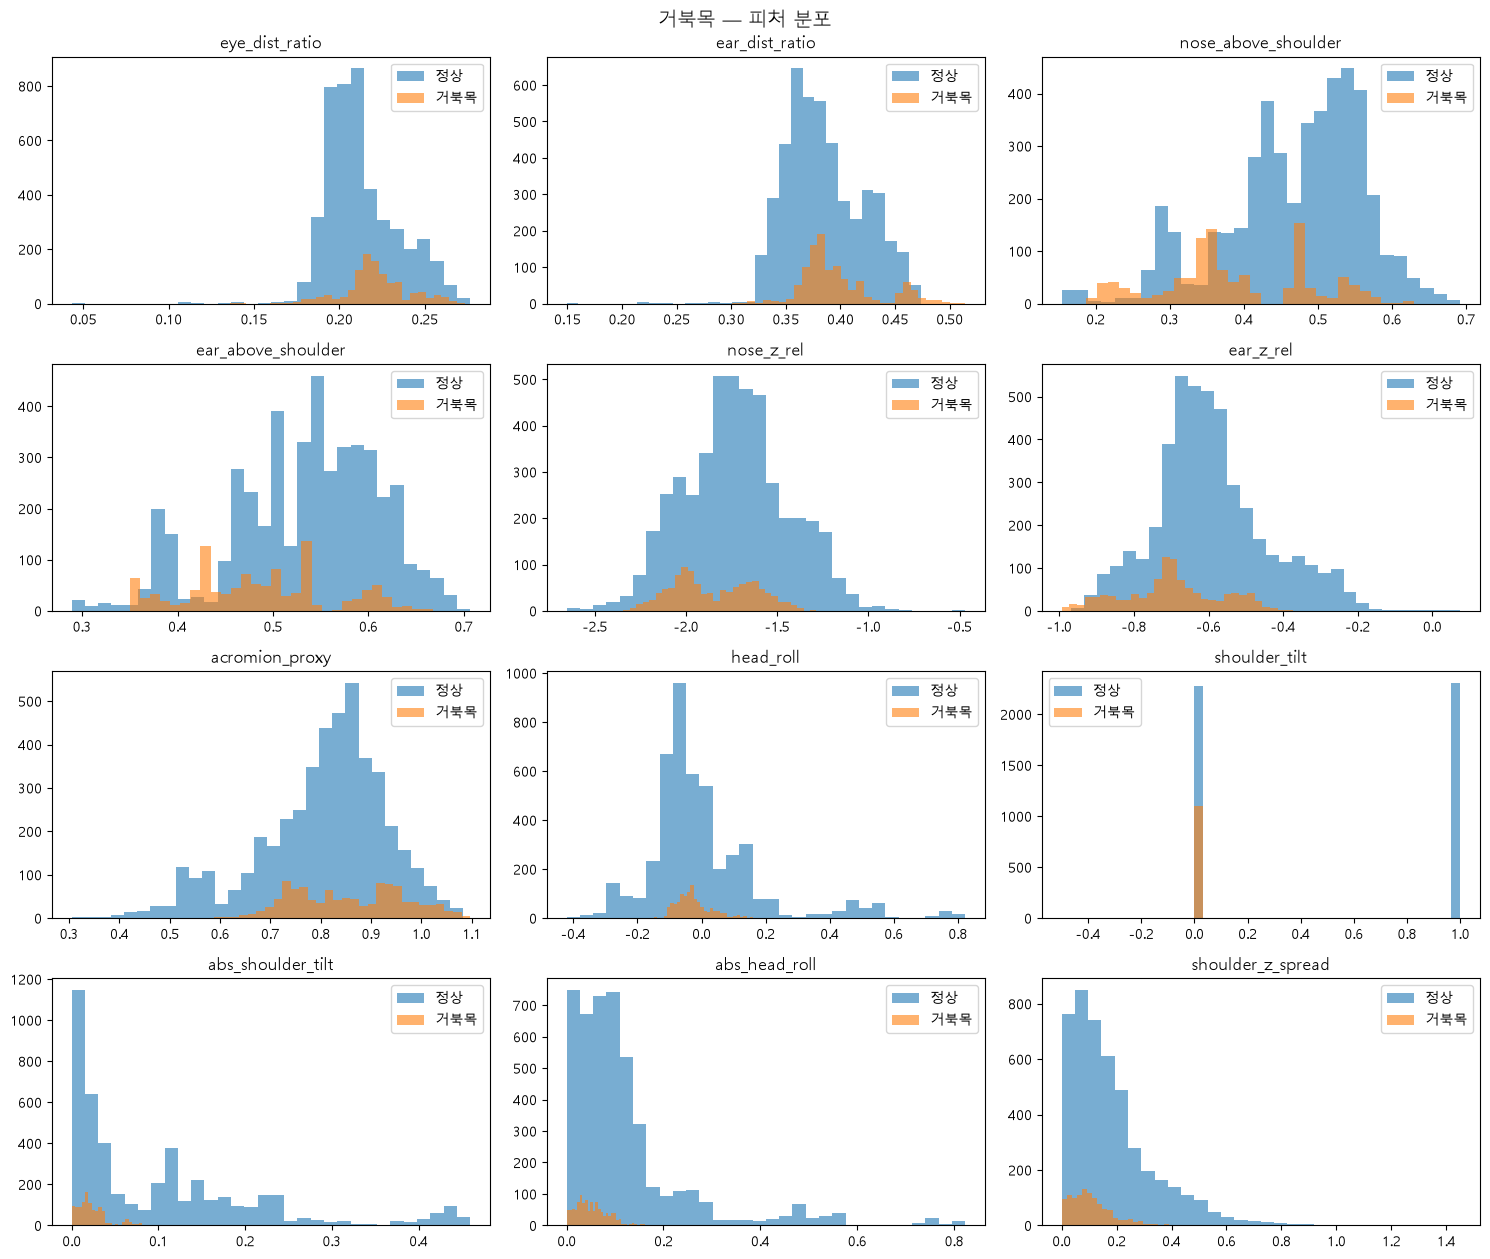

In [10]:
VIZ_LABEL = 'forward_head'  # 'rounded_shoulder' / 'shoulder_tilt' 로 바꿔 보세요

normal = data[data[VIZ_LABEL] == 0]
bad = data[data[VIZ_LABEL] == 1]

n = len(FEATURE_ORDER)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.2 * nrows))
axes = axes.ravel()
for i, feat in enumerate(FEATURE_ORDER):
    axes[i].hist(normal[feat], bins=30, alpha=0.6, label='정상')
    axes[i].hist(bad[feat], bins=30, alpha=0.6, label=LABEL_NAMES_KO[VIZ_LABEL])
    axes[i].set_title(feat)
    axes[i].legend()
for j in range(n, len(axes)):
    axes[j].axis('off')
fig.suptitle(f'{LABEL_NAMES_KO[VIZ_LABEL]} — 피처 분포', fontsize=14)
plt.tight_layout()
plt.show()

## 8. 사람 단위 교차검증 ★

**이 숫자만 믿으세요.** 한 사람을 통째로 빼고 학습해서 그 사람을 맞히게 합니다.
신규 사용자가 서비스를 쓰는 상황과 같은 조건입니다.

- 폴드 = 촬영자 1명 (5명 이하일 때). 폴드별 F1 이 들쭉날쭉하면 사람에 따라 성능 편차가 크다는 뜻입니다.
- **accuracy 대신 F 계열**을 봅니다. 나쁜 자세 프레임이 20%면 전부 '정상'으로 찍어도 accuracy 는 0.8 입니다.
- **F0.5 / F1 / F2 를 함께 출력하고, 채택은 `SELECTION_SCORE`(현재 F2) 하나로 판단합니다.**
  F1 은 중립이 아니라 "정밀도와 재현율이 똑같이 중요하다"는 선언입니다. 이 서비스는 나쁜 자세를
  놓치는 쪽이 더 아프므로 재현율에 4배 가중한 F2 를 기준으로 둡니다.
  헛알림이 더 문제라고 판단이 바뀌면 설정 셀의 `SELECTION_SCORE` 를 `'F0.5'` 로 바꾸면 됩니다 —
  출력·비교표·채택 로직이 전부 그 값을 따라갑니다.

> 이전 버전은 프레임 단위로 분할해서 정확도가 실제보다 크게 부풀려져 있었습니다.
> 여기서 나오는 값이 그보다 낮은 것이 정상입니다.

In [11]:
for label in LABELS:
    info = label_summary(data, label)
    print(f'=== {LABEL_NAMES_KO[label]} ({label}) ===')
    if not info['trainable']:
        print(f'  건너뜀 — 양성 {info["positive"]}프레임/{info["positive_persons"]}명, '
              f'음성 {info["negative"]}프레임/{info["negative_persons"]}명\n')
        continue
    scores = cross_validate_by_person(data, label)
    # 폴드별로는 채택 기준 하나만 본다. 여기가 들쭉날쭉하면 사람에 따라 성능 편차가 크다는 뜻이다.
    print(f'  폴드별 {SELECTION_SCORE}: {np.round(scores[SELECTION_SCORE].to_numpy(), 3)}')
    for name in SCORE_NAMES:
        mark = '  ★ 채택 기준' if name == SELECTION_SCORE else ''
        print(f'  평균 {name:<4} {scores[name].mean():.3f} ± {scores[name].std():.3f}'
              f'   (최저 폴드 {scores[name].min():.3f}){mark}')
    print()

=== 거북목 (forward_head) ===
  폴드별 F1: [0.767 0.    0.953 0.721 0.492]
  평균 F1: 0.587 ± 0.328

=== 라운드숄더 (rounded_shoulder) ===
  폴드별 F1: [0.045 0.505 0.639 0.309 0.591]
  평균 F1: 0.418 ± 0.218

=== 어깨높낮이 (shoulder_tilt) ===
  폴드별 F1: [1. 1. 1. 1. 1.]
  평균 F1: 1.000 ± 0.000



## 9. 평가 리포트 + 최종 학습

자세별로 두 가지를 합니다.

1. **평가** — 검증 폴드에서의 예측만 모아 리포트를 만듭니다. 학습에 쓴 데이터로 채점하지 않습니다.
   **recall(재현율)을 보세요.** 나쁜 자세를 놓치는 것이 오탐보다 나쁩니다.
   `classification_report` 는 F1 만 보여 주므로 그 아래에 F0.5 / F1 / F2 를 한 줄로 더 찍습니다
   (★ 표시가 채택 기준인 `SELECTION_SCORE`).
2. **최종 학습** — 성능 추정이 끝났으니 배포용 모델은 가진 데이터를 전부 써서 다시 학습합니다.

In [12]:
models = {}   # label -> (model, scaler)

for label in LABELS:
    if not label_summary(data, label)['trainable']:
        print(f'=== {LABEL_NAMES_KO[label]} — 데이터 부족으로 건너뜀 ===\n')
        continue
    report, scores = evaluate_by_person(data, label)
    print(f'=== {LABEL_NAMES_KO[label]} ({label}) — 사람 단위 검증 결과 ===')
    print(report)
    # classification_report 는 F1 만 보여 준다. 재현율에 무게를 준 F2 와 그 반대인 F0.5 를 같이 찍는다.
    print(format_scores(scores), '\n')
    models[label] = train_final(data, label)

print('최종 학습 완료:', ', '.join(LABEL_NAMES_KO[l] for l in models) or '없음')

=== 거북목 (forward_head) — 사람 단위 검증 결과 ===
              precision    recall  f1-score   support

          정상       0.92      0.89      0.90      4584
         거북목       0.59      0.68      0.63      1104

    accuracy                           0.85      5688
   macro avg       0.76      0.78      0.77      5688
weighted avg       0.86      0.85      0.85      5688

혼동행렬 (행=실제, 열=예측):
[[4071  513]
 [ 355  749]]
F1: 0.633

=== 라운드숄더 (rounded_shoulder) — 사람 단위 검증 결과 ===
              precision    recall  f1-score   support

          정상       0.88      0.77      0.82      4541
       라운드숄더       0.40      0.60      0.48      1147

    accuracy                           0.73      5688
   macro avg       0.64      0.68      0.65      5688
weighted avg       0.78      0.73      0.75      5688

혼동행렬 (행=실제, 열=예측):
[[3494 1047]
 [ 463  684]]
F1: 0.475

=== 어깨높낮이 (shoulder_tilt) — 사람 단위 검증 결과 ===
              precision    recall  f1-score   support

          정상       1.00      1.00      1.00  

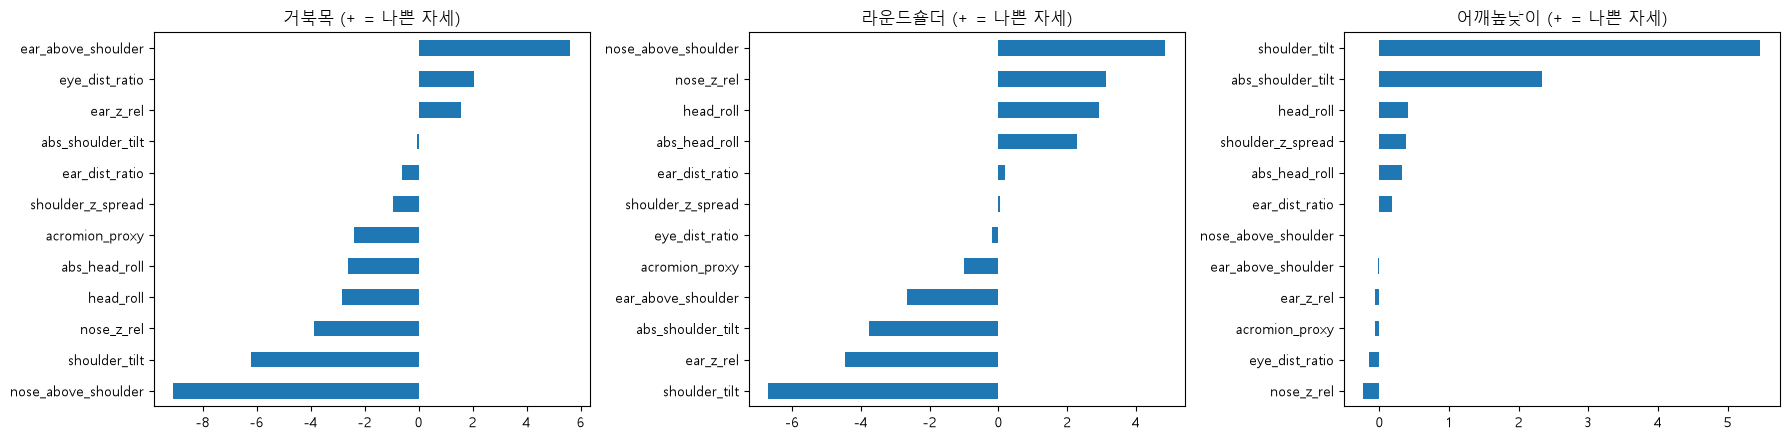

,거북목,라운드숄더,어깨높낮이
eye_dist_ratio,2.057,-0.182,-0.143
ear_dist_ratio,-0.611,0.187,0.178
nose_above_shoulder,-9.079,4.849,-0.006
ear_above_shoulder,5.614,-2.666,-0.016
nose_z_rel,-3.882,3.126,-0.228
ear_z_rel,1.577,-4.473,-0.065
acromion_proxy,-2.404,-0.996,-0.069
head_roll,-2.840,2.929,0.409
shoulder_tilt,-6.225,-6.685,5.466
abs_shoulder_tilt,-0.055,-3.769,2.333


In [13]:
# 자세별 피처 가중치. 부호와 크기가 상식과 맞는지 확인하는 용도다.
# 예상과 반대 부호로 큰 값이 나오면 라벨이 뒤집혔거나 피처 정의가 잘못됐을 가능성이 높다.
if models:
    fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 4.5), squeeze=False)
    for ax, (label, (model, _)) in zip(axes[0], models.items()):
        pd.Series(model.coef_[0], index=FEATURE_ORDER).sort_values().plot.barh(ax=ax)
        ax.set_title(f'{LABEL_NAMES_KO[label]} (+ = 나쁜 자세)')
    plt.tight_layout()
    plt.show()
    display(pd.DataFrame({LABEL_NAMES_KO[l]: m.coef_[0] for l, (m, _) in models.items()},
                         index=FEATURE_ORDER).round(3))
else:
    print('학습된 모델이 없습니다.')

## 10. 모델 export → JSON

자세별로 `models/` 에 파일 하나씩 저장합니다.

- `THRESHOLD`: O/X 2단계 기준 (참고용)
- `WARNING`/`SEVERE`: 3단계(정상/주의/심각) 경계 — `predict.py` 웹캠 표시에 쓰입니다

백엔드는 이 확률을 `app.posture.hybrid.severity-probabilities` 경계로 심각도 0~5 로 바꿉니다.

추론식: `z = Σ coef·(f-mean)/std + intercept`, `prob = 1/(1+exp(-z))`

In [14]:
THRESHOLD = 0.5
# 설정 셀의 값을 그대로 쓴다. 여기에 숫자를 다시 적으면 두 곳이 조용히 어긋난다
# (실제로 LEVEL_WARNING 을 0.5 로 올렸을 때 이 줄만 0.4 로 남아 있었다).
WARNING = LEVEL_WARNING
SEVERE = LEVEL_SEVERE

for label, (model, scaler) in models.items():
    filename = MODEL_FILES[label]
    export_model(model, scaler, filename, threshold=THRESHOLD, warning=WARNING, severe=SEVERE)
    print(f'저장: {MODELS_DIR / filename}  ({LABEL_NAMES_KO[label]})')

print(f'''
──────────────────────────────────────────────────────────
백엔드에 반영하려면:

  cp ai/models/*.json backend/src/main/resources/models/

그리고 backend/src/main/resources/application.yml 의
app.posture.hybrid.*-model 경로를 채우세요.
──────────────────────────────────────────────────────────
⚠️ 피처가 {len(FEATURE_ORDER)}개입니다. 백엔드 PostureMlFeatures 와
   posture-lab.html 의 extractMlFeatures() 도 같은 피처를 갖고 있어야 합니다.
   빠진 게 있으면 서버 기동 시 어떤 피처가 없는지 알려주며 멈춥니다.

   이번에 추가된 피처: abs_shoulder_tilt, abs_head_roll, shoulder_z_spread
                       (shoulder_z_rel 은 nose_z_rel 과 중복이라 제거)
──────────────────────────────────────────────────────────''')

저장: c:\Users\SSAFY\S15P11C106\ai\models\turtleneck_model.json  (거북목)
저장: c:\Users\SSAFY\S15P11C106\ai\models\rounded_shoulder_model.json  (라운드숄더)
저장: c:\Users\SSAFY\S15P11C106\ai\models\shoulder_tilt_model.json  (어깨높낮이)

──────────────────────────────────────────────────────────
백엔드에 반영하려면:

  cp ai/models/*.json backend/src/main/resources/models/

그리고 backend/src/main/resources/application.yml 의
app.posture.hybrid.*-model 경로를 채우세요.
──────────────────────────────────────────────────────────
⚠️ 피처가 12개입니다. 백엔드 PostureMlFeatures 와
   posture-lab.html 의 extractMlFeatures() 도 같은 피처를 갖고 있어야 합니다.
   빠진 게 있으면 서버 기동 시 어떤 피처가 없는지 알려주며 멈춥니다.

   이번에 추가된 피처: abs_shoulder_tilt, abs_head_roll, shoulder_z_spread
                       (shoulder_z_rel 은 nose_z_rel 과 중복이라 제거)
──────────────────────────────────────────────────────────


## 11. (선택) 웹캠 실시간 검증

학습한 모델을 웹캠으로 확인합니다. 실행하면 **별도 창**이 뜨고, 창에서 `q` 키로 종료.
3단계로 표시: GOOD(초록) / WARNING(주황) / SEVERE(빨강).

In [15]:
def _sigmoid(z):
    return 1.0 / (1.0 + math.exp(-z))

def predict_prob(feats, model):
    z = model['intercept']
    for name, mean, std, coef in zip(model['feature_order'], model['mean'],
                                     model['std'], model['coef']):
        z += coef * (feats[name] - mean) / std
    return _sigmoid(z)

def classify_level(prob, levels):
    if prob >= levels.get('severe', 0.7):
        return 'SEVERE', (0, 0, 255)
    if prob >= levels.get('warning', 0.4):
        return 'WARNING', (0, 165, 255)
    return 'GOOD POSTURE', (0, 200, 0)

def _landmarks_to_points(landmark, w, h):
    return {name: [landmark[POSE_LANDMARKS[name]].x * w,
                   landmark[POSE_LANDMARKS[name]].y * h,
                   landmark[POSE_LANDMARKS[name]].z * w,
                   landmark[POSE_LANDMARKS[name]].visibility]
            for name in LANDMARK_NAMES}

print('추론 함수 정의 완료')

추론 함수 정의 완료


In [19]:
def run_webcam(camera=0, smooth=10):
    """학습한 모델을 웹캠으로 확인한다. 있는 모델만 골라 자세별로 한 줄씩 표시한다."""
    loaded = {}
    for label, filename in MODEL_FILES.items():
        path = MODELS_DIR / filename
        if path.exists():
            loaded[label] = json.loads(path.read_text(encoding='utf-8'))
    if not loaded:
        raise FileNotFoundError(f'{MODELS_DIR} 에 모델 JSON이 없습니다. 먼저 학습·export 하세요.')
    print('불러온 모델:', ', '.join(LABEL_NAMES_KO[l] for l in loaded))

    hist = {label: deque(maxlen=smooth) for label in loaded}
    cap = cv2.VideoCapture(camera, cv2.CAP_DSHOW)
    if not cap.isOpened():
        raise RuntimeError(f'카메라 열기 실패 (camera={camera})')
    print('웹캠 실행 중 — 창에서 q 로 종료')

    with mp_pose.Pose(static_image_mode=False, model_complexity=POSE_MODEL_COMPLEXITY,
                      min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            h, w = frame.shape[:2]
            result = pose.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            if result.pose_landmarks:
                pts = _landmarks_to_points(result.pose_landmarks.landmark, w, h)
                if points_visible(pts):
                    feats = compute_features(pts)
                    if feats is not None:
                        for name in LANDMARK_NAMES:
                            cv2.circle(frame, (int(pts[name][0]), int(pts[name][1])), 4, (0, 200, 255), -1)
                        cv2.rectangle(frame, (10, 10), (400, 30 + 34 * len(loaded)), (0, 0, 0), -1)
                        for i, (label, spec) in enumerate(loaded.items()):
                            hist[label].append(predict_prob(feats, spec))
                            prob = sum(hist[label]) / len(hist[label])
                            text, color = classify_level(prob, spec.get('levels', {}))
                            y = 40 + 34 * i
                            cv2.putText(frame, f'{label:<17}{prob:.2f} {text}', (20, y),
                                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
            cv2.imshow('Posture detector (q to quit)', frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
    cap.release()
    cv2.destroyAllWindows()

# 실행하려면 아래 주석 해제:
run_webcam()

불러온 모델: 거북목, 라운드숄더, 어깨높낮이
웹캠 실행 중 — 창에서 q 로 종료


---

# 12. 개인 기준선 델타 학습 (`train_delta`)

지금까지의 모델은 **절대 기준**입니다. 목이 원래 긴 사람은 바른 자세로 앉아 있어도
`ear_above_shoulder` 가 크게 나와서 거북목 확률이 높게 잡힙니다.
규칙 기반은 캘리브레이션 기준선 대비 편차로 판정하니 이 문제가 없는데,
하이브리드는 심각도를 모델이 정하므로 개인차 보정이 통째로 빠져 있습니다.

여기서는 **"이 사람의 바른 자세 대비 얼마나 벗어났는가"** 를 피처로 추가해 다시 학습합니다.

## 기준선을 어디서 얻나

런타임에서는 입장 전 캘리브레이션(몇 초간 바른 자세 캡처 → 피처 평균)이 그 역할을 합니다.
학습 데이터에도 같은 것이 이미 있습니다 — **`*_good.mp4`, 즉 라벨이 전부 0인 프레임**입니다.
사람별로 그 프레임들의 피처 평균을 내면 런타임 캘리브레이션과 같은 절차가 됩니다.

## 원본 피처를 버리지 않는 이유

델타 `d = f - baseline_p` 에서 `baseline_p` 는 그 사람에게 고정된 상수이고,
체형은 정확히 그 상수 안에 들어 있습니다. **빼는 순간 산술적으로 소거됩니다.**

| | baseline | 현재 | delta |
|---|---|---|---|
| A (목 긴 사람) | 0.90 | 1.00 | +0.10 |
| B (목 짧은 사람) | 0.60 | 0.70 | +0.10 |

델타만 쓰면 모델에게 A 와 B 는 **완전히 같은 입력**입니다. 그게 노린 효과이긴 하지만,
같이 잃는 것이 둘 있습니다.

1. **같은 델타가 같은 심각도가 아닙니다.** `acromion_proxy` 같은 지표는 실제 목 각도와
   선형 관계가 아니라, 0.60→0.70 과 0.90→1.00 은 곡선 위 다른 구간입니다.
   절대값이 있어야 모델이 델타를 그 위치에 맞게 해석할 수 있습니다.
2. **기준선 자체가 나쁜 자세일 때 잡을 수 없습니다.** 캘리브레이션 때 이미 구부정했던 사람은
   계속 구부정해도 델타가 0 이라 영원히 정상입니다. 이건 규칙 기반이 가진 약점 그대로이고,
   하이브리드가 절대 기준이라서 갖고 있던 유일한 장점을 버리는 것이기도 합니다.
   원본을 같이 넣으면 "델타는 0 인데 절대값이 집단 정상 범위 밖"을 볼 수 있습니다.

그래서 원본 12개 + 델타를 **함께** 넣고 모델이 고르게 둡니다.

> **대신 치르는 비용:** 원본을 남기면 모델이 개인차를 *여전히 쓸 수 있습니다.*
> 강제 개인화가 아니라 선택지를 주는 것이라, 6명 데이터에서는 "p3 의 체형이면 거북목"처럼
> 사람을 외울 위험이 남습니다. 사람 단위 교차검증으로 그게 드러나게 하고,
> 학습 뒤 **델타 쪽에 가중치가 실렸는지** 계수로 확인합니다(12-4 셀).
> 원본 쪽에만 실렸다면 개인화는 실패한 것입니다.

## 기준선 프레임은 학습에서 뺍니다 ★

기준선을 만든 바로 그 프레임을 학습에도 쓰면, 그 프레임의 델타는 정의상 0 근처입니다.
모델은 "델타 ≈ 0 이면 정상"을 외우고 검증 점수만 오릅니다.
그래서 정상 프레임의 절반(`BASELINE_HOLDOUT`)을 기준선 전용으로 떼어 두고 학습에서 제외합니다.
런타임에서도 캘리브레이션 프레임은 판정 대상이 아니므로 조건이 같습니다.

> **비교는 같은 행에서 합니다.** 홀드아웃으로 행이 줄었으니, 기존 모델도 *줄어든 같은 데이터*로
> 다시 교차검증해서 맞대야 공정합니다. 피처만 다르고 행은 동일하게 둡니다.

In [ ]:
# 12-1. 델타 학습 설정

# 델타를 만들 피처. 12개 전부 넣지 않는 이유는 6명 데이터에 피처 24개면 과적합하기 때문이다.
# 사람마다 값이 크게 다른(= 개인차가 노이즈로 들어오는) 축만 고른다.
DELTA_FEATURES = [
    'ear_above_shoulder',    # 목 길이·앉은키 차이가 그대로 들어간다. 거북목 주지표
    'ear_z_rel',             # 귀-어깨 깊이차. 어깨 두께 개인차
    'acromion_proxy',        # 귀-어깨 측면거리 근사
    'eye_dist_ratio',        # 얼굴 크기 / 카메라 거리
    'shoulder_tilt_signed',  # 원래 어깨가 비대칭인 사람 보정 (부호 유지)
    'head_roll',             # 평소 고개 기울기
]

# 부호 있는 델타에 절댓값을 하나 더 붙일 피처.
#
# ⚠️ abs_shoulder_tilt - baseline[abs_shoulder_tilt] 가 아니라
#    abs(shoulder_tilt_signed - baseline[shoulder_tilt_signed]) 여야 한다.
#    전자는 "원래 왼쪽으로 기운 사람이 같은 크기로 오른쪽으로 기울면 델타 0"이 되어
#    기울기가 반대로 뒤집힌 것을 정상으로 본다. 규칙 기반이 쓰는 정의도 후자다
#    (RuleBasedPostureDetector.judgeShoulderTilt: abs(current - baseline)).
ABS_OF_DELTA = ['shoulder_tilt_signed', 'head_roll']

DELTA_FEATURE_ORDER = (
    FEATURE_ORDER
    + [f'd_{f}' for f in DELTA_FEATURES]
    + [f'abs_d_{f}' for f in ABS_OF_DELTA]
)

# 기준선 계산에만 쓰고 학습에서는 뺄 정상 프레임의 비율.
BASELINE_HOLDOUT = 0.5

# 기존 모델과 파일명을 분리한다. 같은 이름으로 덮으면 지금 백엔드가 그대로 읽어 버리고,
# 델타를 뺄 줄 모르는 서버가 원본 피처를 델타 자리에 넣어 조용히 틀린 확률을 낸다.
DELTA_MODEL_FILES = {l: f.replace('_model.json', '_delta_model.json')
                     for l, f in MODEL_FILES.items()}

_unknown = [f for f in DELTA_FEATURES + ABS_OF_DELTA if f not in FEATURE_ORDER]
assert not _unknown, f'FEATURE_ORDER 에 없는 피처를 델타로 지정했습니다: {_unknown}'

print(f'원본 {len(FEATURE_ORDER)}개 + 델타 {len(DELTA_FEATURES)}개 '
      f'+ 절댓값 델타 {len(ABS_OF_DELTA)}개 = {len(DELTA_FEATURE_ORDER)}개')
print('기준선 홀드아웃:', f'{BASELINE_HOLDOUT:.0%}')
print('출력 파일:', ', '.join(DELTA_MODEL_FILES.values()))

In [ ]:
# 12-2. 델타 학습 함수

def build_person_baselines(data, holdout=BASELINE_HOLDOUT, seed=0):
    """사람별 '바른 자세' 기준선 = 라벨이 전부 0인 프레임의 피처 평균.

    런타임 캘리브레이션(입장 전 몇 초 캡처 → averageBaseline)과 같은 절차다.
    학습 때 다른 방식으로 만들면 배포 후 들어오는 기준선과 분포가 어긋난다.

    holdout 만큼의 정상 프레임을 기준선 전용으로 떼어 그 인덱스를 함께 돌려준다.
    호출부가 학습에서 빼야 한다. 안 빼면 델타가 정의상 0인 프레임으로 학습해서
    모델이 '델타 0 = 정상'을 외우고 검증 점수만 오른다.

    @return (person -> Series[FEATURE_ORDER], 학습에서 뺄 인덱스)
    """
    good = data[(data[LABELS] == 0).all(axis=1)]
    if good.empty:
        raise RuntimeError(
            '라벨이 전부 0인 프레임이 없습니다. 사람마다 바른자세 영상(*_good)이 필요합니다.')

    rng = np.random.default_rng(seed)
    baselines, holdout_index = {}, []
    for person, group in good.groupby('person'):
        idx = group.index.to_numpy()
        rng.shuffle(idx)
        # 최소 1장은 남긴다. 정상 프레임이 아주 적은 사람도 기준선은 있어야 한다.
        picked = idx[:max(1, int(len(idx) * holdout))]
        baselines[person] = data.loc[picked, FEATURE_ORDER].mean()
        holdout_index.extend(picked.tolist())

    missing = sorted(set(data['person'].unique()) - set(baselines))
    if missing:
        raise RuntimeError(
            f'바른자세 프레임이 없는 촬영자: {missing}\n'
            f'이 사람들은 기준선을 만들 수 없어 델타 학습에 넣을 수 없습니다.')
    return baselines, pd.Index(holdout_index)


def make_delta_dataset(data, baselines, holdout_index):
    """원본 피처 + 개인 기준선 대비 델타를 붙인 학습 데이터.

    기준선 전용 프레임은 여기서 빠진다. 이후 비교·학습은 모두 이 DataFrame 위에서 한다.
    """
    df = data.drop(index=holdout_index).copy()
    base = pd.DataFrame([baselines[p] for p in df['person']], index=df.index)
    for f in DELTA_FEATURES:
        df[f'd_{f}'] = df[f] - base[f]
    # 부호 있는 델타를 먼저 만들고 절댓값을 취한다(설정 셀 주석 참고).
    for f in ABS_OF_DELTA:
        df[f'abs_d_{f}'] = (df[f] - base[f]).abs()
    return df


def cross_validate_on(data, label, features):
    """cross_validate_by_person 과 같지만 피처 목록을 받는다. 원본 vs 델타 비교용.

    반환은 행=폴드, 열=F0.5/F1/F2 인 DataFrame 이다. 원본과 델타를 같은 폴드·같은 행으로
    비교해야 하므로 분할기(make_cv)도 데이터도 건드리지 않고 features 만 바꾼다.
    """
    return _cv_scores(data, label, features)


def evaluate_delta_by_person(data, label):
    """검증 폴드 예측만 모은 리포트 + F0.5/F1/F2. evaluate_by_person 의 델타판."""
    y = data[label].to_numpy(int)
    y_pred = _oof_predict(data, label, DELTA_FEATURE_ORDER)
    return _report_text(y, y_pred, label), fbeta_all(y, y_pred)


def train_delta(data, label):
    """배포용 델타 모델. train_final 과 같되 피처가 DELTA_FEATURE_ORDER 다.

    data 는 make_delta_dataset 을 통과한 DataFrame 이어야 한다.
    """
    missing = [f for f in DELTA_FEATURE_ORDER if f not in data.columns]
    if missing:
        raise ValueError(
            f'델타 열이 없습니다: {missing}\nmake_delta_dataset() 을 먼저 통과시키세요.')
    X = data[DELTA_FEATURE_ORDER].to_numpy(float)
    y = data[label].to_numpy(int)
    scaler = StandardScaler().fit(X)
    model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(scaler.transform(X), y)
    return model, scaler


def export_delta_model(model, scaler, filename, threshold=0.5,
                       warning=LEVEL_WARNING, severe=LEVEL_SEVERE):
    """델타 모델 JSON. 추론식은 기존과 같고, 델타를 먼저 만들어야 한다는 정보가 더 붙는다.

    서버는 feature_order 를 보고 값을 꺼내는데 d_* / abs_d_* 는 프레임 피처만으로는
    만들 수 없다. delta_features / abs_delta_features 를 읽어 캘리브레이션 기준선에서
    빼야 한다는 뜻이고, model_kind 가 그 구현이 필요하다는 표시다.

    ⚠️ 지금 백엔드(LogisticPostureModel)는 이 파일을 읽으면 기동에서 멈춘다.
       verifyFeaturesKnown 이 'd_ear_above_shoulder' 를 PostureMlFeatures 에서 못 찾기
       때문이다. 조용히 틀리는 것보다 낫고, 서빙 구현이 끝나기 전에는 그게 맞는 동작이다.
    """
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    payload = {
        'model_kind': 'delta-v1',
        'feature_order': DELTA_FEATURE_ORDER,
        'raw_features': FEATURE_ORDER,
        'delta_features': DELTA_FEATURES,
        'abs_delta_features': ABS_OF_DELTA,
        # 서버가 캘리브레이션 때 평균을 내서 저장해야 하는 피처. 델타 계산의 피감수다.
        'baseline_features': sorted(set(DELTA_FEATURES) | set(ABS_OF_DELTA)),
        'mean': scaler.mean_.tolist(),
        'std': scaler.scale_.tolist(),
        'coef': model.coef_[0].tolist(),
        'intercept': float(model.intercept_[0]),
        'threshold': threshold,
        'levels': {'warning': warning, 'severe': severe},
    }
    (MODELS_DIR / filename).write_text(json.dumps(payload, indent=2), encoding='utf-8')
    return payload

print('델타 학습 함수 정의 완료 (build_person_baselines / make_delta_dataset / train_delta)')

In [ ]:
# 12-3. 실행 — 기준선 생성 + 원본 vs 델타 비교 ★
#
# 이 표가 A안의 채택 여부를 정한다. 델타가 원본보다 낮으면 서빙 쪽은 손대지 않는다.
#
# 채택 기준은 SELECTION_SCORE(F2) 하나다. F1·F0.5 도 같이 찍는데, 그건 참고가 아니라
# "지표를 바꾸면 결론이 뒤집히는가"를 보는 용도다. 셋 다 같은 방향이면 안심하고 채택하고,
# F2 만 좋아졌다면 그 이득이 재현율 쪽에만 있다는 뜻이라 헛알림 증가를 따로 확인해야 한다.
#
# 평균보다 '최저 폴드'를 먼저 보자. 개인차 보정의 목적은 평균을 올리는 것보다
# 특정 사람에게서 무너지는 것(거북목 원본: 어떤 폴드 F1 0.000)을 막는 데 있다.
# '개선한 폴드'도 같이 낸다 — 6명에서 평균 차이 0.02 는 폴드 하나로 뒤집히지만,
# 6명 중 5명에서 좋아졌다면 그건 우연으로 설명하기 어렵다.

baselines, holdout_index = build_person_baselines(data)
delta_data = make_delta_dataset(data, baselines, holdout_index)

print(f'기준선 {len(baselines)}명 · 기준선 전용 프레임 {len(holdout_index)}개 제외')
print(f'학습 대상: {len(data)} → {len(delta_data)}개\n')

# 사람별 기준선이 실제로 다른지 본다. 여기가 다 비슷하면 개인차 보정할 것이 없다는 뜻이다.
baseline_df = pd.DataFrame(baselines).T[DELTA_FEATURES]
display(baseline_df.round(3))
print('사람 간 표준편차 / 전체 표준편차 (클수록 개인차가 크다):')
display((baseline_df.std() / data[DELTA_FEATURES].std()).round(3).to_frame('ratio'))

rows = []
for label in LABELS:
    if not label_summary(delta_data, label)['trainable']:
        print(f'{LABEL_NAMES_KO[label]}: 데이터 부족으로 건너뜀')
        continue
    base_scores = cross_validate_on(delta_data, label, FEATURE_ORDER)        # 같은 행, 원본 피처
    delta_scores = cross_validate_on(delta_data, label, DELTA_FEATURE_ORDER)  # 같은 행, 델타 포함
    base_sel, delta_sel = base_scores[SELECTION_SCORE], delta_scores[SELECTION_SCORE]
    row = {'자세': LABEL_NAMES_KO[label]}
    for name in SCORE_NAMES:
        row[f'원본 {name}'] = base_scores[name].mean()
        row[f'델타 {name}'] = delta_scores[name].mean()
    # 아래 4개와 '차이' 는 전부 채택 기준(SELECTION_SCORE) 하나로 낸다. 지표마다 최저폴드를
    # 따로 두면 표만 넓어지고 무엇을 보고 정하는지가 흐려진다.
    row['차이'] = delta_sel.mean() - base_sel.mean()
    row['원본 최저폴드'] = base_sel.min()
    row['델타 최저폴드'] = delta_sel.min()
    row['원본 편차'] = base_sel.std()
    row['델타 편차'] = delta_sel.std()
    row['개선한 폴드'] = f'{int((delta_sel > base_sel).sum())}/{len(base_sel)}'
    rows.append(row)

comparison = pd.DataFrame(rows).set_index('자세')
print(f'★ 채택 판단은 {SELECTION_SCORE} 기준 — "차이" · "최저폴드" · "개선한 폴드" 열이 그것이다.')
print(f'   나머지 {" · ".join(n for n in SCORE_NAMES if n != SELECTION_SCORE)} 열은 '
      f'결론이 지표에 따라 뒤집히는지 보는 용도다.\n')
display(comparison.round(3))

improved = comparison[comparison['차이'] > 0].index.tolist()
print('\n개선:', ', '.join(improved) or '없음')
print('악화:', ', '.join(comparison[comparison['차이'] <= 0].index.tolist()) or '없음')

In [ ]:
# 12-4. 최종 학습 + 개인화가 실제로 일어났는지 확인 ★
#
# 원본 피처를 남겨 뒀으므로 모델이 델타를 무시하고 절대값만 써도 학습은 된다.
# 그러면 개인차 보정은 하나도 안 된 채 피처만 늘어난 셈이다.
# 표준화된 피처의 계수라 크기를 그대로 비교할 수 있다. 델타 쪽 비중이 낮으면 실패다.

delta_models = {}
for label in LABELS:
    if not label_summary(delta_data, label)['trainable']:
        print(f'=== {LABEL_NAMES_KO[label]} — 데이터 부족으로 건너뜀 ===\n')
        continue
    report, scores = evaluate_delta_by_person(delta_data, label)
    print(f'=== {LABEL_NAMES_KO[label]} ({label}) — 델타 모델 사람 단위 검증 ===')
    print(report)
    print(format_scores(scores), '\n')
    delta_models[label] = train_delta(delta_data, label)

if delta_models:
    delta_cols = [f for f in DELTA_FEATURE_ORDER if f.startswith(('d_', 'abs_d_'))]
    weights = pd.DataFrame({LABEL_NAMES_KO[l]: m.coef_[0] for l, (m, _) in delta_models.items()},
                           index=DELTA_FEATURE_ORDER)

    raw_sum = weights.loc[FEATURE_ORDER].abs().sum()
    delta_sum = weights.loc[delta_cols].abs().sum()
    share = pd.DataFrame({
        '원본 |계수| 합': raw_sum,
        '델타 |계수| 합': delta_sum,
        '델타 비중': delta_sum / (raw_sum + delta_sum),
        # 개수가 다르므로(원본 12개 vs 델타 8개) 피처당 평균도 같이 본다
        '원본 평균': raw_sum / len(FEATURE_ORDER),
        '델타 평균': delta_sum / len(delta_cols),
    })
    display(share.round(3))
    print('델타 비중이 0.3 미만이면 모델이 개인 기준선을 거의 안 쓴 것이다.')
    print('그때는 DELTA_FEATURES 를 잘못 골랐거나, 그 자세가 절대값만으로 충분하다는 뜻이다.\n')

    fig, axes = plt.subplots(1, len(delta_models), figsize=(6.5 * len(delta_models), 6),
                             squeeze=False)
    for ax, label in zip(axes[0], delta_models):
        s = weights[LABEL_NAMES_KO[label]].sort_values()
        colors = ['tab:orange' if i.startswith(('d_', 'abs_d_')) else 'tab:blue' for i in s.index]
        s.plot.barh(ax=ax, color=colors)
        ax.set_title(f'{LABEL_NAMES_KO[label]} (주황 = 델타, + = 나쁜 자세)')
    plt.tight_layout()
    plt.show()
    display(weights.round(3))
else:
    print('학습된 델타 모델이 없습니다.')

In [ ]:
# 12-5. 델타 모델 export
#
# 자세별 델타 모델을 전부 내보낸다.
#
# 원래는 12-3 비교표에서 개선된 자세만 내보냈다(EXPORT_ONLY_IMPROVED = True). 그러면 어깨높낮이는
# 델타가 F1 -0.024 로 조금 낮아서 파일 자체가 생기지 않고, 서빙에서 두 방식을 실제로 맞대 볼
# 방법이 없어진다. 6명 데이터에서 0.024 는 폴드 하나가 흔들리면 뒤집히는 크기라, 학습 시점에
# 잘라 버리는 것보다 파일을 남기고 dev 패널에서 비교해 정하는 편이 낫다.
#
# 개선된 것만 내보내려면 다시 True 로 둔다. 건너뛴 자세는 아래에서 이유와 함께 출력된다.

EXPORT_ONLY_IMPROVED = False

exported = []
for label, (model, scaler) in delta_models.items():
    name_ko = LABEL_NAMES_KO[label]
    if EXPORT_ONLY_IMPROVED and name_ko in comparison.index and comparison.loc[name_ko, '차이'] <= 0:
        print(f'건너뜀: {name_ko} — 델타가 원본보다 '
              f'{SELECTION_SCORE} {comparison.loc[name_ko, "차이"]:+.3f}')
        continue
    filename = DELTA_MODEL_FILES[label]
    export_delta_model(model, scaler, filename, threshold=THRESHOLD,
                       warning=WARNING, severe=SEVERE)
    exported.append(filename)
    print(f'저장: {MODELS_DIR / filename}  ({name_ko})')

# 사람별 기준선도 함께 남긴다. 서빙 구현이 캘리브레이션 평균을 어떤 형식으로 저장해야
# 하는지 맞춰 보는 참조값이고, 백엔드 테스트 픽스처로도 쓸 수 있다.
if exported:
    baseline_path = MODELS_DIR / 'person_baselines.json'
    baseline_path.write_text(json.dumps(
        {p: {f: float(v[f]) for f in sorted(set(DELTA_FEATURES) | set(ABS_OF_DELTA))}
         for p, v in baselines.items()}, indent=2), encoding='utf-8')
    print(f'저장: {baseline_path}  (학습 데이터 기준선 {len(baselines)}명)')

print(f'''
──────────────────────────────────────────────────────────
⚠️ 이 파일들은 아직 백엔드에 복사하면 안 됩니다.

   지금 LogisticPostureModel 은 feature_order 의 이름을 PostureMlFeatures 에서
   찾는데, 'd_ear_above_shoulder' 같은 델타 이름은 프레임 피처만으로 만들 수 없어
   기동에서 멈춥니다. 델타를 만들려면 캘리브레이션 기준선이 서버까지 와야 하고,
   그 경로가 아직 없습니다 (아래 12-6 참고).

   파일명이 기존 모델(*_model.json)과 다르므로 실수로 로드될 일은 없습니다.

내보낸 파일: {', '.join(exported) or '없음'}
──────────────────────────────────────────────────────────''')

## 12-6. 실측 결과와 서빙에 남은 작업

### 현재 데이터(6명·5688프레임)로 돌린 결과

라벨 누수를 고친 뒤 측정한 값입니다. 시드가 고정돼 있어 그대로 재현됩니다.

| 자세 | 원본 F1 | 델타 F1 | 차이 | 델타 계수 비중 |
|---|---|---|---|---|
| 거북목 | 0.617 | **0.676** | **+0.059** | 0.325 |
| 라운드숄더 | 0.664 | 0.380 | −0.285 | 0.234 |
| 어깨높낮이 | 0.913 | 0.889 | −0.024 | 0.495 |

**거북목만 개선됐고, 그것도 폭이 작습니다.** 델타 계수 비중 0.325 는 모델이 개인 기준선을
쓰긴 하되 절대값에 더 의존한다는 뜻입니다. 6명으로 피처를 20개까지 늘린 대가를 감안하면
"효과는 있으나 결정적이지는 않다"가 정직한 결론입니다.

폴드별로 보면 거북목은 원본 `[0.956, 0.000, 0.914, 0.725, 0.493]` →
델타 `[0.937, 0.000, 0.965, 0.782, 0.699]` 입니다.
**F1 0.000 인 폴드는 델타로도 살아나지 않았습니다.** 그 사람은 개인차 문제가 아니라
라벨이나 촬영 조건 쪽을 봐야 합니다.

> 라운드숄더가 크게 나빠진 것은 이상하지 않습니다. 애초에 정면 웹캠으로 잡기 어려운 자세라
> 원본 모델도 폴드 편차가 컸고, 백엔드는 이미 이 자세의 판정을 걷어냈습니다.

### 서빙에 남은 작업

델타 모델을 실제로 쓰려면 **캘리브레이션 기준선이 서버까지 와야** 합니다.
지금은 브라우저가 12개 ML 피처를 캘리브레이션 중에도 뽑고 있지만
`averageBaseline()` 이 v1 필드 4개만 골라내고 나머지를 버립니다.

| # | 파일 | 할 일 |
|---|---|---|
| 1 | `frontend/src/lib/pose/postureFeatures.ts` | `averageBaseline` 이 `mlFeatures` 평균도 담아 반환 (`baseline_features` 목록) |
| 2 | `frontend/src/types/posture.ts` | `PostureBaseline` 에 `mlBaseline?` 추가 |
| 3 | `backend/.../dto/PostureBaseline.java` | nullable `mlBaseline` 필드 추가. **기존 JSON 은 null 로 읽히므로 역호환** |
| 4 | `backend/.../service/LogisticPostureModel.java` | `deltaFeatures` / `absDeltaFeatures` 읽기, `probability(ml, mlBaseline)` 오버로드 |
| 5 | `backend/.../service/HybridPostureDetector.java` | `detect()` 가 받은 `baseline` 을 `withModelSeverity` 로 전달 |
| 6 | `application.yml` | `hybrid.forward-head-model` 을 `turtleneck_delta_model.json` 으로 |

### 주의할 것

- **기존 사용자는 전부 재캘리브레이션이 필요합니다.** `mlBaseline` 이 없는 기준선으로는
  델타를 만들 수 없습니다. 이때 조용히 규칙 기반으로 흘리면 하이브리드로 돌린 줄 알고
  실험 데이터를 버리게 되므로, `Judgement.skipped(type, "NO_ML_BASELINE")` 으로 보류하고
  재캘리브레이션을 유도하는 편이 낫습니다.
- **`severity-probabilities` 를 다시 맞춰야 합니다.** 델타 모델은 확률 분포가 달라져서
  기존 경계(`0.40,0.55,0.70,0.85,0.95`)가 그대로 맞지 않습니다.
- **거북목 하나만 바꾸는 것이 맞습니다.** 어깨높낮이는 기존 모델을 그대로 두세요.
  `EXPORT_ONLY_IMPROVED = True` 가 그렇게 되도록 걸러 줍니다.

### 이번에 같이 고친 것 — 라벨 누수

`FEATURE_ORDER` 의 `'shoulder_tilt'` 와 `LABELS` 의 `'shoulder_tilt'` 이름이 같아서,
`load_dataset` 이 라벨을 넣을 때 **피처값이 0/1 라벨로 덮어써지고** 있었습니다.

```python
feats = compute_features(points)   # feats['shoulder_tilt'] = 0.0134  (비율)
for label in LABELS:
    feats[label] = int(r[label])   # feats['shoulder_tilt'] = 1       (라벨!)
```

그래서 어깨높낮이 모델은 정답을 피처로 받아 F1 1.000 이 나왔고, 거북목·라운드숄더 모델도
"이 사람이 어깨가 기울었는지"를 공짜로 받고 있었습니다. 피처 이름을
`shoulder_tilt_signed` 로 바꿔 충돌을 없앴고, 재발을 막는 assert 를 설정 셀에 넣었습니다.

**배포된 모델은 영향이 없습니다.** 백엔드는 이미 같은 이름으로 고쳐져 있고
(`PostureMlFeatures.valueOf` 가 두 이름을 모두 받습니다),
`backend/src/main/resources/models/*.json` 도 `shoulder_tilt_signed` 로 학습된 것입니다.
노트북만 옛 이름으로 남아 있어서, 재실행했다면 누수가 되살아났을 상황이었습니다.

누수를 걷어내니 어깨높낮이 F1 이 1.000 → 0.913 으로 내려왔습니다. 이쪽이 실제 성능입니다.